In [1]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset('titanic')

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
df_num = df[['age','fare','sibsp','parch','survived']]

df_num.head()

,age,fare,sibsp,parch,survived
0,22.0,7.2500,1,0,0
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,1
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,0


In [3]:
df_num = df_num.fillna(df_num.median())

df_num.isnull().sum()

age         0
fare        0
sibsp       0
parch       0
survived    0
dtype: int64

In [4]:
df_num['almost_constant'] = 1

In [5]:
df_num.head()

,age,fare,sibsp,parch,survived,almost_constant
0,22.0,7.2500,1,0,0,1
1,38.0,71.2833,1,0,1,1
2,26.0,7.9250,0,0,1,1
3,35.0,53.1000,1,0,1,1
4,35.0,8.0500,0,0,0,1


####  When to Use Variance Thresholding?

**Core Idea:**  
A feature with **near-zero variance** means it barely changes across all samples — it carries almost no information.  
Example: A column where 99% of patients have the same value → useless for prediction.

**Formula:**
$$\text{Var}(X) = \frac{1}{n} \sum_{i=1}^{n}(x_i - \bar{x})^2$$

** USE THIS WHEN:**
- Features are **continuous/numerical**
- You suspect some features are nearly constant across samples
- You want a quick pre-processing step before any model
- High-dimensional data (100s or 1000s of features)

** DON'T USE WHEN:**
- Features are categorical (variance is meaningless for categories)
- You haven't normalized features yet (a feature with large values will always show high variance — misleading!)

In [6]:
from sklearn.feature_selection import VarianceThreshold

X = df_num.drop('survived', axis=1)

selector = VarianceThreshold(threshold=0.01)

X_selected = selector.fit_transform(X)

selected_features = X.columns[selector.get_support()]

print(selected_features)

Index(['age', 'fare', 'sibsp', 'parch'], dtype='str')


**Core Idea:**  
Pearson's correlation measures the **linear relationship** between two continuous variables.  
Range: **-1 to +1**
- +1 = Perfect positive linear relationship
- -1 = Perfect negative linear relationship  
- 0  = No linear relationship

**Formula:**
$$r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \cdot \sum(y_i-\bar{y})^2}}$$

**Two uses in Feature Selection:**
1. **Feature-Target Correlation:** Keep features with |r| > threshold (e.g., 0.1)
2. **Feature-Feature Correlation:** Remove one of two highly correlated features (redundancy)

**USE THIS WHEN:**
- Both features AND target are **continuous/numerical**
- You're solving a **regression problem**
- You want to detect multicollinearity (highly correlated features hurt linear models)

** DON'T USE WHEN:**
- Target is categorical (use Chi² or F-test instead)
- Relationships are non-linear (Pearson's r will miss them)
- Features are categorical

In [9]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df['Price'] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [10]:
corr_matrix = df.corr()

corr_matrix['Price'].sort_values(
    ascending=False
)

Price         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: Price, dtype: float64

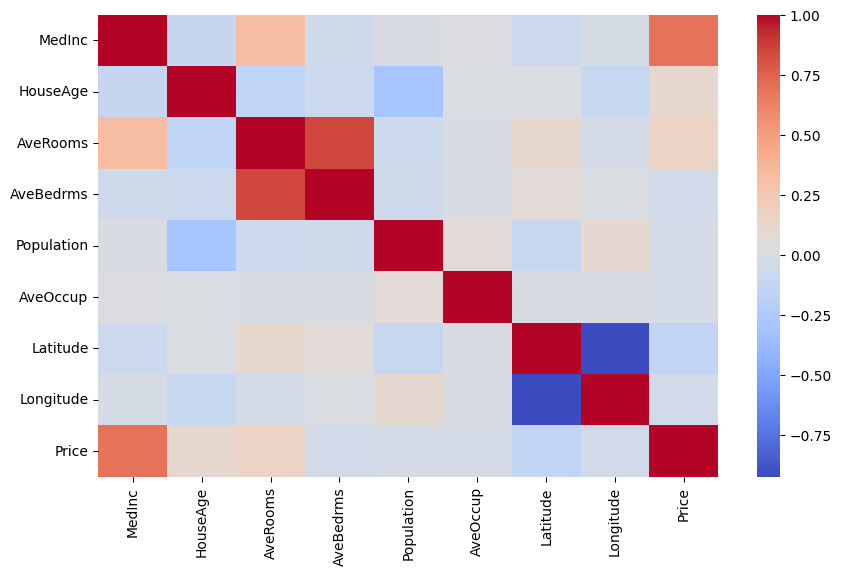

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=False
)

plt.show()

In [12]:
corr_target = abs(df.corr()['Price'])

selected_features = corr_target[
    corr_target > 0.3
]

print(selected_features)

MedInc    0.688075
Price     1.000000
Name: Price, dtype: float64


**Core Idea:**  
The Chi-Squared test checks whether a feature and the target are **statistically independent**.  
- If they are independent → feature is useless for prediction → **remove it**
- If they are NOT independent → feature has a significant relationship with target → **keep it**

**Formula:**
$$\chi^2 = \sum \frac{(O - E)^2}{E}$$
Where O = Observed frequency, E = Expected frequency (if independent)

**How it works:**  
- High χ² score → **strong dependence** with target → keep feature  
- Low χ² score → **weak dependence** with target → remove feature  
- p-value < 0.05 → statistically significant relationship

**USE THIS WHEN:**
- Features are **categorical** or **non-negative integer counts**
- Target is **categorical** (classification problem)
- You need to test independence between variables

**DON'T USE WHEN:**
- Features contain **negative values** (chi² requires non-negative input)
- Features are continuous (use F-test instead)
- Target is continuous (use correlation or F-regression)

In [13]:
from sklearn.datasets import load_breast_cancer


data = load_breast_cancer()

X  = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [16]:
print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [15]:
#non-negative values required
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [17]:
from sklearn.feature_selection import chi2

chi_scores, p_values = chi2(
    X_scaled,
    y
)

In [18]:
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Chi2 Score': chi_scores,
    'P-value': p_values
})

feature_scores = feature_scores.sort_values(
    by='Chi2 Score',
    ascending=False
)

feature_scores.head(10)

,Feature,Chi2 Score,P-value
7,mean concave points,52.405743,4.514020e-13
27,worst concave points,46.341648,9.933002e-12
6,mean concavity,46.186395,1.075210e-11
23,worst area,35.043882,3.223582e-09
22,worst perimeter,34.438091,4.400270e-09
20,worst radius,34.124937,5.168467e-09
26,worst concavity,31.563031,1.930704e-08
3,mean area,29.328594,6.108761e-08
2,mean perimeter,26.528902,2.596246e-07
0,mean radius,24.897293,6.046728e-07


In [19]:
from sklearn.feature_selection import SelectKBest

selector = SelectKBest(
    score_func=chi2,
    k=10
)

X_selected = selector.fit_transform(
    X_scaled,
    y
)

selected_features = X.columns[
    selector.get_support()
]

print(selected_features)

Index(['mean radius', 'mean perimeter', 'mean area', 'mean concavity',
       'mean concave points', 'worst radius', 'worst perimeter', 'worst area',
       'worst concavity', 'worst concave points'],
      dtype='str')


**Core Idea:**  
ANOVA tests whether the **mean** of a continuous feature differs significantly **across different classes**.  
If a feature has the same mean for all classes → it's useless for distinguishing them.  
If a feature has very different means across classes → it's highly discriminative.

**Formula (F-statistic):**
$$F = \frac{\text{Between-group variance}}{\text{Within-group variance}} = \frac{MS_{between}}{MS_{within}}$$

**How it works:**  
- High F-score → feature means differ greatly across classes → very useful → **keep**
- Low F-score → feature means are similar across all classes → not useful → **remove**

**USE THIS WHEN:**
- Features are **continuous/numerical**
- Target is **categorical** (2+ classes — works for multi-class!)
- You want to find features that best **separate the classes**

**DON'T USE WHEN:**
- Features are categorical (use Chi² instead)
- Target is continuous (use `f_regression` or Pearson's correlation)
- You assume non-linear class boundaries (F-test assumes normality)


In [20]:
from sklearn.datasets import load_iris


iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = iris.target

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [21]:
from sklearn.feature_selection import f_classif

f_scores, p_values = f_classif(
    X,
    y
)

In [22]:
results = pd.DataFrame({
    'Feature': X.columns,
    'F Score': f_scores,
    'P Value': p_values
})

results.sort_values(
    by='F Score',
    ascending=False
)

,Feature,F Score,P Value
2,petal length (cm),1180.161182,2.856777e-91
3,petal width (cm),960.007147,4.169446e-85
0,sepal length (cm),119.264502,1.669669e-31
1,sepal width (cm),49.160040,4.492017e-17


In [23]:
selector = SelectKBest(
    score_func=f_classif,
    k=2
)

X_selected = selector.fit_transform(
    X,
    y
)

selected_features = X.columns[
    selector.get_support()
]

print(selected_features)

Index(['petal length (cm)', 'petal width (cm)'], dtype='str')
